# Verify Model Improvement over Loop 1 After Loop 2.

## Prepare the Notebook.

In [59]:
import logging
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

from sc_exp_design.metrics import compute_e_distance, compute_mmd

### Add Extra Environmental Variables.

In [2]:
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import get_forward_model, generate_with_condition, get_shuffled_populations
from plot_utils import make_scatter_plot

### Setup Logger.

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] - %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)


## Load Model from Loop 1.

### Load Configurations from Loop 1.

In [4]:
with hydra.initialize(
    config_path="../../../../../inverse/loss_guidance/config",
    version_base=None
):
    config_loop1 = hydra.compose(
        config_name="run_inverse",
        overrides=[
            "annotation=bloodplus",
            "paths=bloodplus"
        ]
    )
scatter_cols = config_loop1.annotation.scatter_columns
protocol_cols = config_loop1.annotation.protocol_columns

### Load Loop 1 Model.

In [5]:
forward_model_loop1, (
    pert_resp_prediction_model_loop1,
    target_prediction_model_loop1
) = get_forward_model(config_loop1, logger=logger)
pert_resp_prediction_model_loop1.velocity_field.eval()
target_prediction_model_loop1.target_prediction_model.eval()


[2026-08-07 09:22:12] - __main__: Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
[2026-08-07 09:25:00] - __main__: Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
 

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=64, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)

### Fit Label Encoder.

In [6]:
train_adata_g = target_prediction_model_loop1.train_data.adata
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())


### Retrieve Standardization Paramaters.

In [7]:
# ---- Perturbation Response Prediction Model ----
adata_phi_loop1 = pert_resp_prediction_model_loop1.train_data.adata
loop1_channel_params = adata_phi_loop1.uns["X_channel_params"]
loop1_scatter_params = adata_phi_loop1.uns["X_scatter_params"]

# ---- Cell Type Classifier ----
adata_g_loop1 = target_prediction_model_loop1.train_data.adata
loop1_channel_params_g = adata_g_loop1.uns["X_channel_params"]
loop1_scatter_params_g = adata_g_loop1.uns["X_scatter_params"]


## Load Model from Loop 2.

### Load Configurations from Loop 2.

In [8]:
with hydra.initialize(
    config_path="../../../../../inverse/loss_guidance/config",
    version_base=None
):
    config_loop2 = hydra.compose(
        config_name="run_inverse",
        overrides=[
            "annotation=bloodplus",
            "paths=bloodplus_loop2",
            "paths.perturbation_prediction_path=/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/forward_model/loop2/2026-06-17_17-19-47/fresh-bee-21_FlowMatching.pkl"
        ]
    )

### Load Loop 2 Model.

In [9]:
forward_model_loop2, (
    pert_resp_prediction_model_loop2,
    target_prediction_model_loop2
) = get_forward_model(config_loop2, logger=logger)
pert_resp_prediction_model_loop2.velocity_field.eval()
target_prediction_model_loop2.target_prediction_model.eval()


[2026-08-07 09:25:03] - __main__: Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/forward_model/loop2/2026-06-17_17-19-47/fresh-bee-21_FlowMatching.pkl...
[2026-08-07 09:27:46] - __main__: Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=32, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type_leiden): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=32, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)

### Retrieve Standardization Paramaters.

In [10]:
# ---- Perturbation Response Prediction Model ----
adata_phi_loop2 = pert_resp_prediction_model_loop2.train_data.adata
loop2_channel_params = adata_phi_loop2.uns["X_channel_params"]
loop2_scatter_params = adata_phi_loop2.uns["X_scatter_params"]

# ---- Cell Type Classifier ----
adata_g_loop2 = target_prediction_model_loop2.train_data.adata
loop2_channel_params_g = adata_g_loop2.uns["X_channel_params"]
loop2_scatter_params_g = adata_g_loop2.uns["X_scatter_params"]


## Prepare Condition Data from Loop 2.5

### Read Residual Data from Loop 2.5

In [11]:
loop2p5_res_h5ad_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2p5/replicate/adata_500k_residual.h5ad"
adata_res_loop2p5 = sc.read_h5ad(loop2p5_res_h5ad_path)
adata_res_loop2p5

AnnData object with n_obs × n_vars = 500000 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Retrieve Original Data.

In [12]:
X_channel = adata_res_loop2p5.X
X_scatter = adata_res_loop2p5.obs[scatter_cols].astype(float).values
X = np.concatenate((X_channel, X_scatter), axis=1)
print(f"{X_channel.shape=}, {X_scatter.shape=}, {X.shape=}")

X_channel.shape=(500000, 20), X_scatter.shape=(500000, 6), X.shape=(500000, 26)


### Prepare Condition Data.

In [13]:
meta_df_loop2p5 = adata_res_loop2p5.obs
cond_data =  meta_df_loop2p5[protocol_cols].astype(float).values
X_cond = np.unique(cond_data, axis=0)

cond_data_log1p = np.log1p(cond_data)
X_cond_log1p = np.log1p(X_cond)
X_cond.shape

(4, 12)

### Retrieve Correspondence between Experiment Number and Index.

In [14]:
exp_num_to_cond_idx = {}
for cond_idx, cond in enumerate(X_cond):
    cond_mask = np.all(cond_data == cond, axis=1)
    adata_cond = adata_res_loop2p5[cond_mask].copy()
    cond_exp_num = adata_cond.obs["experiment_number"].astype(int).unique().item()
    exp_num_to_cond_idx[cond_exp_num] = cond_idx
exp_idx_to_num = {v: k for k, v in exp_num_to_cond_idx.items()}
exp_num_to_cond_idx, exp_idx_to_num

({248: 0, 250: 1, 251: 2, 249: 3}, {0: 248, 1: 250, 2: 251, 3: 249})

### Mean Variance Plot per Experiment.

In [15]:
# ---- Define color for plotting ----
color_loop1 = '#669bbc'   # light blue

# ---- Iterate over unique conditions ----
for idx, cond in tqdm(enumerate(X_cond)):
    # ---- Get mask for current condition ----
    cond_idxs = np.all(cond_data == cond, axis=1)

    # ---- Get Real data ----
    x_channel = X_channel[cond_idxs]

    # ---- Compute statistics ----
    x_chann_mean = x_channel.mean(0)
    x_chann_std = x_channel.std(0)

    # ---- Mean-Var Plot ----
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(x_chann_mean, x_chann_std, color=color_loop1, alpha=0.7, s=200)

    # ---- Diagonal reference line ----
    all_vals = np.concatenate([x_chann_mean, x_chann_std])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val],
            linewidth=3, alpha=0.5, color="gray")

    # ---- Save without any legend ----
    fig.tight_layout()
    plt.savefig(f'output/mean_std_cond_{idx:03d}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

4it [00:02,  1.87it/s]


### Compute Neighbors and UMAP.

In [16]:
compute_neighbors_graph = False
if compute_neighbors_graph:
    sc.pp.neighbors(adata_res_loop2p5)
    sc.tl.umap(adata_res_loop2p5)


### Plot UMAP by Experiment Number.

In [17]:
exp_numbers = sorted(adata_res_loop2p5.obs.experiment_number.unique())
if compute_neighbors_graph:
    for exp in exp_numbers:
        sc.pl.embedding(adata_res_loop2p5, "umap", s=20, groups=exp, color=["experiment_number"], frameon=False)

### Plot UMAP by Marker Value.

In [18]:
if compute_neighbors_graph:
    sc.pl.embedding(adata_res_loop2p5, "umap", s=20, color=adata_res_loop2p5.var_names, frameon=False)

## Classify Data.

### Classify with Loop 1 Model.

In [19]:
# ---- Apply Standardization ----
X_channel_real_trasnf1_g = (X_channel - loop1_channel_params_g["mean"])/loop1_channel_params_g["std"]
X_scatter_real_trasnf1_g = (X_scatter - loop1_scatter_params_g["mean"])/loop1_scatter_params_g["std"]
X_real_trasnf1_g = np.concatenate((X_channel_real_trasnf1_g, X_scatter_real_trasnf1_g), axis=1)
X_torch_trasnf1_g = torch.from_numpy(X_real_trasnf1_g).to(torch.float32)

# ----- Create dataset for classification ----
dataset_g_loop1 = TensorDataset(X_torch_trasnf1_g)
dataloader_loop1 = DataLoader(dataset_g_loop1, batch_size=10_000, shuffle=False)

# ---- List to store the predictions ----
ct_logits_loop1 = []
ct_probs_loop1 = []
ct_preds_loop1 = []

# ---- Classify cell types ---
with torch.no_grad():
    for xb in tqdm(dataloader_loop1):
        xb = xb[0]
        xb = xb.to(target_prediction_model_loop1.device)

        y_logits = target_prediction_model_loop1.predict(xb)["cell_type"]
        y_probs = torch.nn.functional.softmax(y_logits, dim=-1)
        y_label = y_probs.argmax(-1)

        ct_logits_loop1.append(y_logits.cpu().detach().numpy())
        ct_probs_loop1.append(y_probs.cpu().detach().numpy())
        ct_preds_loop1.append(y_label.cpu().detach().numpy())

ct_logits_loop1 = np.concatenate(ct_logits_loop1)
ct_probs_loop1 = np.concatenate(ct_probs_loop1)
ct_preds_loop1 = np.concatenate(ct_preds_loop1)

# ---- Decode predicted cell types ----
ct_preds_loop1 = classes[ct_preds_loop1]

# ---- Write back to anndata ----
adata_res_loop2p5.obs["cell_type_loop1"] = ct_preds_loop1
adata_res_loop2p5

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:10<00:00,  4.94it/s]


AnnData object with n_obs × n_vars = 500000 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type_loop1'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'pos

### Classify with Loop 2 Model.

In [20]:
# ---- Apply Standardization ----
X_channel_real_trasnf2_g = (X_channel - loop2_channel_params_g["mean"])/loop2_channel_params_g["std"]
X_scatter_real_trasnf2_g = (X_scatter - loop2_scatter_params_g["mean"])/loop2_scatter_params_g["std"]
X_real_trasnf2_g = np.concatenate((X_channel_real_trasnf2_g, X_scatter_real_trasnf2_g), axis=1)
X_torch_trasnf2_g = torch.from_numpy(X_real_trasnf2_g).to(torch.float32)

# ----- Create dataset for classification ----
dataset_g_loop2 = TensorDataset(X_torch_trasnf2_g)
dataloader_loop2 = DataLoader(dataset_g_loop2, batch_size=10_000, shuffle=False)

# ---- List to store the predictions ----
ct_logits_loop2 = []
ct_probs_loop2 = []
ct_preds_loop2 = []

# ---- Classify cell types ---
with torch.no_grad():
    for xb in tqdm(dataloader_loop1):
        xb = xb[0]
        xb = xb.to(target_prediction_model_loop1.device)

        y_logits = target_prediction_model_loop2.predict(xb)["cell_type_leiden"]
        y_probs = torch.nn.functional.softmax(y_logits, dim=-1)
        y_label = y_probs.argmax(-1)

        ct_logits_loop2.append(y_logits.cpu().detach().numpy())
        ct_probs_loop2.append(y_probs.cpu().detach().numpy())
        ct_preds_loop2.append(y_label.cpu().detach().numpy())

ct_logits_loop2 = np.concatenate(ct_logits_loop2)
ct_probs_loop2 = np.concatenate(ct_probs_loop2)
ct_preds_loop2 = np.concatenate(ct_preds_loop2)

# ---- Decode predicted cell types ----
ct_preds_loop2 = classes[ct_preds_loop2]

# ---- Write back to anndata ----
adata_res_loop2p5.obs["cell_type_loop2"] = ct_preds_loop2
adata_res_loop2p5


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:02<00:00, 17.84it/s]


AnnData object with n_obs × n_vars = 500000 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type_loop1', 'cell_type_loop2'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_step

### Aggregate Proportions Over Cell Types of Interest.

In [21]:
# ---- Define target cell type and optional renaming ---
tgt_cts = [
    "CD14Mono", "CD16Mono", "preProB",
    "EryPro", "HSCs", "ProB", "late_MgkPro"
]
renamed_cts = {
    "late_MgkPro": "MgkPro"
}

# ---- Store for results ----
target_ct_to_idx = {}
mapped_cts = {}

# ---- Loop over cell types ---
for ct_idx, ct in enumerate(classes):
    if ct in tgt_cts:
        ct_label = renamed_cts[ct] if ct in renamed_cts else ct 
        mapped_cts[ct] = ct_label
        target_ct_to_idx[ct_label] = ct_idx
    else:
        mapped_cts[ct] = "Other"

# ---- Map Values ---
adata_res_loop2p5.obs["Cell Type Loop 1"] = adata_res_loop2p5.obs["cell_type_loop1"].map(mapped_cts)
adata_res_loop2p5.obs["Cell Type Loop 2"] = adata_res_loop2p5.obs["cell_type_loop2"].map(mapped_cts)

# ---- Store for results ----
mean_probs1 = np.zeros([len(exp_numbers), len(classes)])
mean_probs2 = np.zeros([len(exp_numbers), len(classes)])
mapped_mean_probs1 = {}
mapped_mean_probs2 = {}
other_probs1 = np.zeros(len(exp_numbers))
other_probs2 = np.zeros(len(exp_numbers))

# ---- Iterate over experiment numbers ----
for exp_idx, exp_num in enumerate(exp_numbers):
    # ---- Get mask ----
    exp_mask = adata_res_loop2p5.obs["experiment_number"] == exp_num

    # ---- Slice data ----
    adata_exp = adata_res_loop2p5[exp_mask].copy()
    ct_p1 = ct_probs_loop1[exp_mask]
    ct_p2 = ct_probs_loop2[exp_mask]

    # ---- Aggregate probabilities ----
    mean_ct_p1 = ct_p1.mean(0)
    mean_ct_p2 = ct_p2.mean(0)

    # ---- Store data ----
    mean_probs1[exp_idx] = mean_ct_p1
    mean_probs2[exp_idx] = mean_ct_p2

# ---- Construct DataFrame ----
mean_probs_df1 = pd.DataFrame(mean_probs1, columns=classes, index=exp_numbers)
mean_probs_df2 = pd.DataFrame(mean_probs2, columns=classes, index=exp_numbers)

# ---- Map Columns for df ----
for ct in classes:
    # --- Get mean probability for current cell type ----
    ct_probs1 = mean_probs_df1[ct].values
    ct_probs2 = mean_probs_df2[ct].values
    
    # --- Handle target cell types ----
    if ct not in tgt_cts:
        other_probs1 = other_probs1 + ct_probs1
        other_probs2 = other_probs2 + ct_probs2
    else:
        mapped_mean_probs1[ct] = ct_probs1
        mapped_mean_probs2[ct] = ct_probs2

# --- Store other cell type probs ----
mapped_mean_probs1["Other"] = other_probs1
mapped_mean_probs2["Other"] = other_probs2

# ---- Store mapped cell type probabilities ----
mapped_mean_probs_df1 = pd.DataFrame(mapped_mean_probs1, index=exp_numbers)
mapped_mean_probs_df2 = pd.DataFrame(mapped_mean_probs2, index=exp_numbers)


### Plot UMAP by Predicted Cell Type.

In [22]:
if compute_neighbors_graph:
    sc.pl.embedding(adata_res_loop2p5, "umap", s=20, color=["cell_type_loop1", "cell_type_loop2"], frameon=False, legend_loc="on data")

## Run Predictions with Alternative Models.

### Define Shared Settings for Prediction.

In [23]:
num_samples = 20_000
num_time_steps = 1000
solver_kwargs = {"method": "euler", "atol": 5e-5, "rtol": 5e-5}

### Predict With Loop 1 Model.

In [24]:
pred_loop1 = generate_with_condition(
    X_cond_log1p,
    forward_model_loop1,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_samples,
    logger=logger,
    cell_type_column="cell_type"
)

[2026-08-07 09:29:32] - __main__: X_gen.shape=(20000, 4, 26), X_channel_gen.shape=(20000, 4, 20), X_scatter_gen.shape=(20000, 4, 6), gen_ct_logits.shape=(20000, 4, 24)


### Parse Prediction Results and Rescale.

In [25]:
# ---- Parse Prediction Dictionaries ----
X_gen_loop1_transf = pred_loop1["X"]
X_channel_gen_loop1_trans = pred_loop1["X_channel"]
X_scatter_gen_loop1_trans = pred_loop1["X_scatter"]
ct_probs_gen_loop1 = pred_loop1["ct_probs"]
print(f"{X_gen_loop1_transf.shape=}, {X_channel_gen_loop1_trans.shape=}, {X_scatter_gen_loop1_trans.shape=}, {ct_probs_gen_loop1.shape=}")

# ---- Get standardization parameters ----
adata_phi_loop1 = pert_resp_prediction_model_loop1.train_data.adata
loop1_channel_params = adata_phi_loop1.uns["X_channel_params"]
loop1_scatter_params = adata_phi_loop1.uns["X_scatter_params"]

# ---- Inverse transform on generated data ----
X_channel_gen_loop1 = X_channel_gen_loop1_trans*loop1_channel_params["std"] + loop1_channel_params["mean"]
X_scatter_gen_loop1 = X_scatter_gen_loop1_trans*loop1_scatter_params["std"] + loop1_scatter_params["mean"]
X_gen_loop1 = np.concatenate((X_channel_gen_loop1, X_scatter_gen_loop1), axis=2)

X_gen_loop1_transf.shape=(20000, 4, 26), X_channel_gen_loop1_trans.shape=(20000, 4, 20), X_scatter_gen_loop1_trans.shape=(20000, 4, 6), ct_probs_gen_loop1.shape=(20000, 4, 24)


### Predict With Loop 2 Model.

In [26]:
pred_loop2 = generate_with_condition(
    X_cond_log1p,
    forward_model_loop2,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_samples,
    logger=logger,
    cell_type_column="cell_type_leiden"
)

[2026-08-07 09:31:18] - __main__: X_gen.shape=(20000, 4, 26), X_channel_gen.shape=(20000, 4, 20), X_scatter_gen.shape=(20000, 4, 6), gen_ct_logits.shape=(20000, 4, 24)


### Parse Prediction Results and Rescale.

In [27]:
# ---- Parse Prediction Dictionaries ----
X_gen_loop2_transf = pred_loop2["X"]
X_channel_gen_loop2_trans = pred_loop2["X_channel"]
X_scatter_gen_loop2_trans = pred_loop2["X_scatter"]
ct_probs_gen_loop2 = pred_loop2["ct_probs"]
print(f"{X_gen_loop2_transf.shape=}, {X_channel_gen_loop2_trans.shape=}, {X_scatter_gen_loop2_trans.shape=}, {ct_probs_gen_loop2.shape=}")

# ---- Inverse transform on generated data ----
X_channel_gen_loop2 = X_channel_gen_loop2_trans*loop2_channel_params["std"] + loop2_channel_params["mean"]
X_scatter_gen_loop2 = X_scatter_gen_loop2_trans*loop2_scatter_params["std"] + loop2_scatter_params["mean"]
X_gen_loop2 = np.concatenate((X_channel_gen_loop2, X_scatter_gen_loop2), axis=2)

X_gen_loop2_transf.shape=(20000, 4, 26), X_channel_gen_loop2_trans.shape=(20000, 4, 20), X_scatter_gen_loop2_trans.shape=(20000, 4, 6), ct_probs_gen_loop2.shape=(20000, 4, 24)


## Inspect Forward Model Prediction Quality.

### Compute Mean Cell Type Probabilities per Experiment.

In [28]:
# ---- Store for results ----
mean_gen_probs1 = np.zeros([len(exp_numbers), len(classes)])
mean_gen_probs2 = np.zeros([len(exp_numbers), len(classes)])

# ---- Iterate over experiment numbers ----
for exp_idx, exp_num_str in enumerate(exp_numbers):
    # --- Retrieve condition index ----
    exp_num = int(exp_num_str)
    cond_idx = exp_num_to_cond_idx[exp_num]

    # ---- Retrieve mean probabilities for current experiment ----
    exp_mean_gen_probs1 = ct_probs_gen_loop1[:, cond_idx].mean(0)
    exp_mean_gen_probs2 = ct_probs_gen_loop2[:, cond_idx].mean(0)

    # ---- Store results for current experiment ----
    mean_gen_probs1[exp_idx] = exp_mean_gen_probs1
    mean_gen_probs2[exp_idx] = exp_mean_gen_probs2

# ---- Store results in DataFrame ----
gen_mean_probs_df1 = pd.DataFrame(mean_gen_probs1, columns=classes, index=exp_numbers)
gen_mean_probs_df2 = pd.DataFrame(mean_gen_probs2, columns=classes, index=exp_numbers)

# ---- Store for results ----
gen_other_probs1 = np.zeros(len(exp_numbers))
gen_other_probs2 = np.zeros(len(exp_numbers))
gen_mapped_mean_probs1 = {}
gen_mapped_mean_probs2 = {}

# ---- Map Columns for df ----
for ct in classes:
    # --- Get mean probability for current cell type ----
    gen_ct_probs1 = gen_mean_probs_df1[ct].values
    gen_ct_probs2 = gen_mean_probs_df2[ct].values
    
    # --- Handle target cell types ----
    if ct not in tgt_cts:
        gen_other_probs1 = gen_other_probs1 + gen_ct_probs1
        gen_other_probs2 = gen_other_probs2 + gen_ct_probs2
    else:
        gen_mapped_mean_probs1[ct] = gen_ct_probs1
        gen_mapped_mean_probs2[ct] = gen_ct_probs2

# --- Store other cell type probs ----
gen_mapped_mean_probs1["Other"] = gen_other_probs1
gen_mapped_mean_probs2["Other"] = gen_other_probs2

# ---- Store mapped cell type probabilities ----
gen_mapped_mean_probs_df1 = pd.DataFrame(gen_mapped_mean_probs1, index=exp_numbers)
gen_mapped_mean_probs_df2 = pd.DataFrame(gen_mapped_mean_probs2, index=exp_numbers)


### Plot Results.

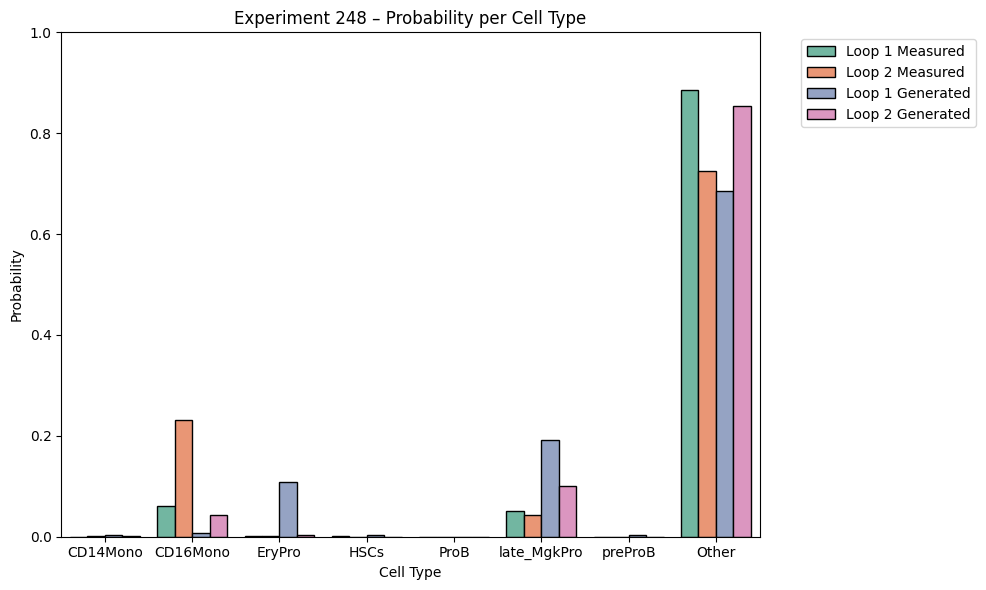

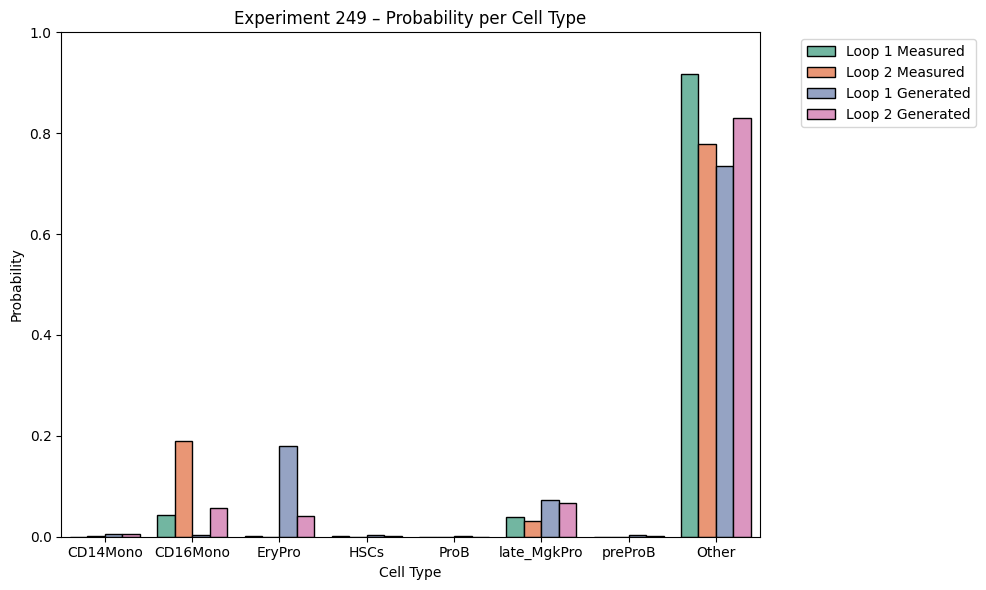

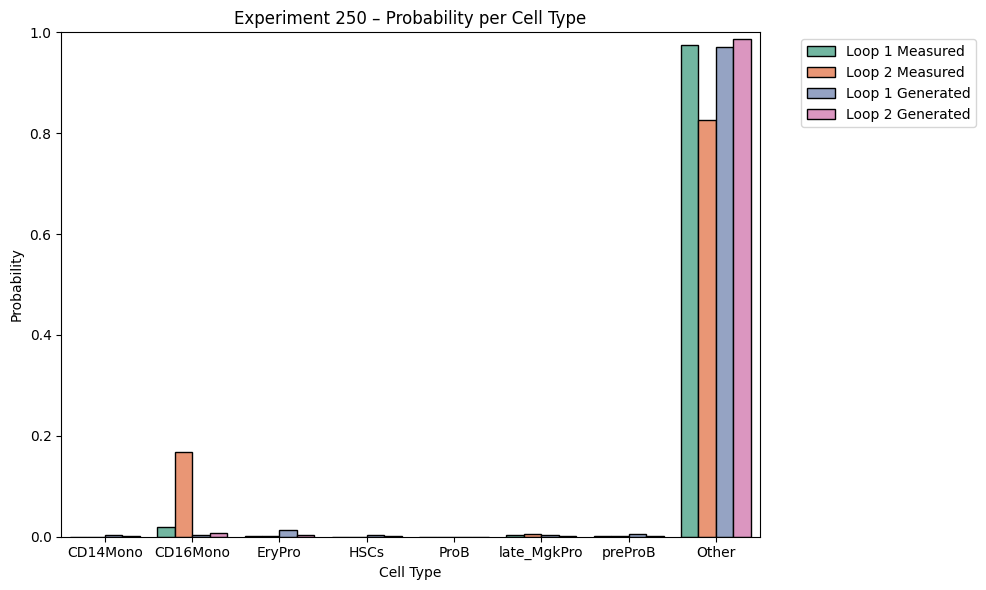

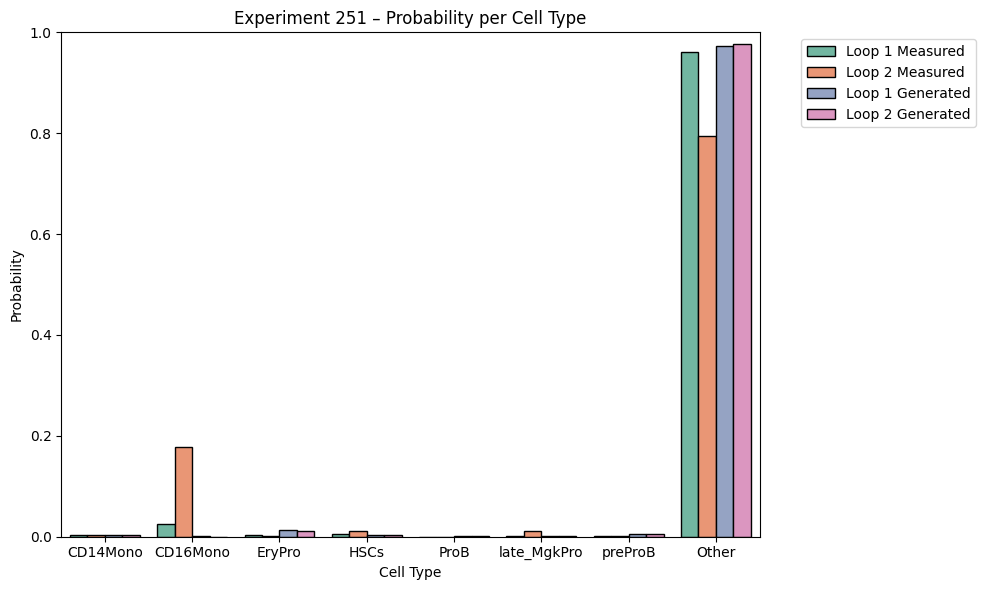

In [29]:
# --- Define map for DataFrames in each case  ---
mapped_dfs = {
    "Loop 1 Measured": mapped_mean_probs_df1,
    "Loop 2 Measured": mapped_mean_probs_df2,
    "Loop 1 Generated": gen_mapped_mean_probs_df1,
    "Loop 2 Generated": gen_mapped_mean_probs_df2,
}

# ---- Iterate over experiment numbers ---
for exp in exp_numbers:
    # ---- Build a temporary long-form DataFrame for this experiment ----
    rows = []
    for case, df in mapped_dfs.items():
        # Get the row for this experiment
        exp_row = df.loc[exp]  # a Series with cell types as index
        for cell_type, prob in exp_row.items():
            rows.append({
                'Cell Type': cell_type,
                'Probability': prob,
                'Case': case
            })
    plot_df = pd.DataFrame(rows)

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_df, x='Cell Type', y='Probability', hue='Case',
                palette='Set2', edgecolor='black')
    plt.title(f'Experiment {exp} – Probability per Cell Type')
    plt.ylim(0, 1)                # probabilities are in [0,1]
    plt.ylabel('Probability')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()                    # pauses until you close the window

## Evaluate Prediction Quality on Cell State Space.

### Transform with Loop 1 Parameters.

In [30]:
X_channel_real_trasnf1 = (X_channel - loop1_channel_params["mean"])/loop1_channel_params["std"]
X_scatter_real_trasnf1 = (X_scatter - loop1_scatter_params["mean"])/loop1_scatter_params["std"]
X_real_trasnf1 = np.concatenate((X_channel_real_trasnf1, X_scatter_real_trasnf1), axis=1)

### Transform with Loop 2 Parameters.

In [31]:
X_channel_real_trasnf2 = (X_channel - loop2_channel_params["mean"])/loop2_channel_params["std"]
X_scatter_real_trasnf2 = (X_scatter - loop2_scatter_params["mean"])/loop2_scatter_params["std"]
X_real_trasnf2 = np.concatenate((X_channel_real_trasnf2, X_scatter_real_trasnf2), axis=1)

### Group the Data for Each Protocol and Compute Metrics.

In [32]:
# ---- Subset strategy ----
n_obs_eval = 1_000

# ---- Store for records ----
records = []

# ---- Iterate over unique conditions ----
for idx, cond in tqdm(enumerate(X_cond)):
    # ---- Get mask for current condition ----
    cond_idxs = np.all(cond_data == cond, axis=1)

    # ---- Get Real data ----
    x = X[cond_idxs][:n_obs_eval]
    x_channel = X_channel[cond_idxs][:n_obs_eval]
    x_scatter = X_scatter[cond_idxs][:n_obs_eval]

    # ========================================================= #
    # ==================== LOOP 1 ============================= #
    # ========================================================= #

    # ---- Loop 1 generated data ----
    X_loop1_cond_gen = X_gen_loop1[:, idx][:n_obs_eval]
    X_channel_loop1_cond_gen = X_channel_gen_loop1[:, idx][:n_obs_eval]
    X_scatter_loop1_cond_gen = X_scatter_gen_loop1[:, idx][:n_obs_eval]

    # ---- Compute energy distance -----
    edist_loop1_X = compute_e_distance(x, X_loop1_cond_gen).item()
    edist_loop1_X_channel = compute_e_distance(x_channel, X_channel_loop1_cond_gen).item()
    edist_loop1_X_scatter = compute_e_distance(x_scatter, X_scatter_loop1_cond_gen).item()

    # ---- Compute MMD -----
    mmd_loop1_X = compute_mmd(x, X_loop1_cond_gen).item()
    mmd_loop1_X_channel = compute_mmd(x_channel, X_channel_loop1_cond_gen).item()
    mmd_loop1_X_scatter = compute_mmd(x_scatter, X_scatter_loop1_cond_gen).item()

    # ========================================================= #
    # ==================== LOOP 2 ============================= #
    # ========================================================= #
    # ---- Loop 2 generated data ----
    X_loop2_cond_gen = X_gen_loop2[:, idx][:n_obs_eval]
    X_channel_loop2_cond_gen = X_channel_gen_loop2[:, idx][:n_obs_eval]
    X_scatter_loop2_cond_gen = X_scatter_gen_loop2[:, idx][:n_obs_eval]

    # ---- Compute energy distance -----
    edist_loop2_X = compute_e_distance(x, X_loop2_cond_gen).item()
    edist_loop2_X_channel = compute_e_distance(x_channel, X_channel_loop2_cond_gen).item()
    edist_loop2_X_scatter = compute_e_distance(x_scatter, X_scatter_loop2_cond_gen).item()

    # ---- Compute MMD -----
    mmd_loop2_X = compute_mmd(x, X_loop2_cond_gen).item()
    mmd_loop2_X_channel = compute_mmd(x_channel, X_channel_loop2_cond_gen).item()
    mmd_loop2_X_scatter = compute_mmd(x_scatter, X_scatter_loop2_cond_gen).item()

    # ---- Update records ----
    records.append(
        {
            "edist_X_loop1": edist_loop1_X,
            "edist_X_channel_loop1": edist_loop1_X_channel,
            "edist_X_scatter_loop1": edist_loop1_X_scatter,

            "edist_X_loop2": edist_loop2_X,
            "edist_X_channel_loop2": edist_loop2_X_channel,
            "edist_X_scatter_loop2": edist_loop2_X_scatter,

            "mmd_X_loop1": mmd_loop1_X,
            "mmd_X_channel_loop1": mmd_loop1_X_channel,
            "mmd_X_scatter_loop1": mmd_loop1_X_scatter,

            "mmd_X_loop2": mmd_loop2_X,
            "mmd_X_channel_loop2": mmd_loop2_X_channel,
            "mmd_X_scatter_loop2": mmd_loop2_X_scatter,
        }
    )

# ---- Create DataFrame with evaluation metrics ----
cell_state_metrics_df = pd.DataFrame(records)
cell_state_metrics_df

4it [00:08,  2.01s/it]


,edist_X_loop1,edist_X_channel_loop1,edist_X_scatter_loop1,edist_X_loop2,edist_X_channel_loop2,edist_X_scatter_loop2,mmd_X_loop1,mmd_X_channel_loop1,mmd_X_scatter_loop1,mmd_X_loop2,mmd_X_channel_loop2,mmd_X_scatter_loop2
0,2.133428e+09,0.611582,2.133428e+09,1.980684e+09,0.050901,1.980684e+09,0.002,0.093394,0.002,0.002,0.007776,0.002
1,4.352436e+10,0.215656,4.352436e+10,1.008123e+09,0.007393,1.008123e+09,0.002,0.064928,0.002,0.002,0.002651,0.002
2,2.274260e+10,0.145717,2.274260e+10,3.166800e+10,0.134347,3.166800e+10,0.002,0.037797,0.002,0.002,0.034976,0.002
3,8.643481e+08,0.409598,8.643481e+08,1.600576e+08,0.080407,1.600576e+08,0.002,0.078925,0.002,0.002,0.016069,0.002


### Construct DataFrame with Marker Statistics.

In [33]:
# ---- Prepare var names ----
var_names = adata_res_loop2p5.var_names.tolist() + scatter_cols

# ---- Store for records ----
records = []

# ---- Iterate over unique conditions ----
for idx, cond in tqdm(enumerate(X_cond)):
    # ---- Get mask for current condition ----
    cond_idxs = np.all(cond_data == cond, axis=1)

    # ========================================================= #
    # ===================== REAL ============================== #
    # ========================================================= #
    # ---- Get Real data ----
    x = X[cond_idxs]
    x_channel = X_channel[cond_idxs]
    x_scatter = X_scatter[cond_idxs]

    # ---- Compute statistics ----
    x_mean = x.mean(0)
    x_std = x.std(0)

    # ---- Get Real data transf 1 ----
    x_trasnf1 = X_real_trasnf1[cond_idxs]
    x_channel_trasnf1 = X_channel_real_trasnf1[cond_idxs]
    x_scatter_trasnf1 = X_scatter_real_trasnf1[cond_idxs]

    # ---- Compute statistics ----
    x_mean_transf1 = x_trasnf1.mean(0)
    x_std_transf1 = x_trasnf1.std(0)

    # ---- Get Real data transf 2 ----
    x_trasnf2 = X_real_trasnf2[cond_idxs]
    x_channel_trasnf2 = X_channel_real_trasnf2[cond_idxs]
    x_scatter_trasnf2 = X_scatter_real_trasnf2[cond_idxs]

    # ---- Compute statistics ----
    x_mean_transf2 = x_trasnf2.mean(0)
    x_std_transf2 = x_trasnf2.std(0)

    # ========================================================= #
    # ==================== LOOP 1 ============================= #
    # ========================================================= #
    # ---- Loop 1 generated data ----
    X_loop1_cond_gen = X_gen_loop1[:, idx]
    X_channel_loop1_cond_gen = X_channel_gen_loop1[:, idx]
    X_scatter_loop1_cond_gen = X_scatter_gen_loop1[:, idx]

    # ---- Compute statistics ----
    X_loop1_cond_mean = X_loop1_cond_gen.mean(0)
    X_loop1_cond_std = X_loop1_cond_gen.std(0)

    # ---- Loop 1 generated data ----
    X_loop1_cond_gen_transf = X_gen_loop1_transf[:, idx]
    X_channel_loop1_cond_gen_transf = X_channel_gen_loop1_trans[:, idx]
    X_scatter_loop1_cond_gen_transf = X_scatter_gen_loop1_trans[:, idx]

    # ---- Compute statistics ----
    X_loop1_cond_mean_transf = X_loop1_cond_gen_transf.mean(0)
    X_loop1_cond_std_transf = X_loop1_cond_gen_transf.std(0)

    # ========================================================= #
    # ==================== LOOP 2 ============================= #
    # ========================================================= #
    # ---- Loop 2 generated data ----
    X_loop2_cond_gen = X_gen_loop2[:, idx]
    X_channel_loop2_cond_gen = X_channel_gen_loop2[:, idx]
    X_scatter_loop2_cond_gen = X_scatter_gen_loop2[:, idx]

    # ---- Compute statistics ----
    X_loop2_cond_mean = X_loop2_cond_gen.mean(0)
    X_loop2_cond_std = X_loop2_cond_gen.std(0)

    # ---- Loop 2 generated data ----
    X_loop2_cond_gen_transf = X_gen_loop2_transf[:, idx]
    X_channel_loop2_cond_gen_transf = X_channel_gen_loop2_trans[:, idx]
    X_scatter_loop2_cond_gen_transf = X_scatter_gen_loop2_trans[:, idx]

    # ---- Compute statistics ----
    X_loop2_cond_mean_transf = X_loop2_cond_gen_transf.mean(0)
    X_loop2_cond_std_transf = X_loop2_cond_gen_transf.std(0)

    # ---- Update records ----
    records.append(
        {

            # ---- Original Scale ----
            **{
                f"{var}_mean_real": x_mean[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_mean_loop1": X_loop1_cond_mean[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_mean_loop2": X_loop2_cond_mean[idx] for idx, var in enumerate(var_names)
            },

            **{
                f"{var}_std_real": x_std[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_std_loop1": X_loop1_cond_std[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_std_loop2": X_loop2_cond_std[idx] for idx, var in enumerate(var_names)
            },

            # ---- Transformed scale loop 1 ----
            **{
                f"{var}_mean_real_transf1": x_mean_transf1[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_mean_loop1_transf": X_loop1_cond_mean_transf[idx] for idx, var in enumerate(var_names)
            },

            **{
                f"{var}_std_real_transf1": x_std_transf1[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_std_loop1_transf": X_loop1_cond_std_transf[idx] for idx, var in enumerate(var_names)
            },

            # ---- Transformed scale loop 2 ----
            **{
                f"{var}_mean_real_transf2": x_mean_transf2[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_mean_loop2_transf": X_loop2_cond_mean_transf[idx] for idx, var in enumerate(var_names)
            },

            **{
                f"{var}_std_real_transf2": x_std_transf2[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_std_loop2_transf": X_loop2_cond_std_transf[idx] for idx, var in enumerate(var_names)
            },
        }
    )

# ---- Create DataFrame with evaluation metrics ----
markers_stats_df = pd.DataFrame(records)
markers_stats_df

4it [00:00, 11.36it/s]


,CD49c_mean_real,CD41a_mean_real,CD117_mean_real,CD38_mean_real,HLADR_mean_real,EPCR_mean_real,CD135_mean_real,CD56_mean_real,CD15_mean_real,CD123_mean_real,...,CD45RA_std_loop2_transf,CD34_std_loop2_transf,CD235a_std_loop2_transf,CD19_std_loop2_transf,FSC-A :: FSC - Area_std_loop2_transf,FSC-H :: FSC - Height_std_loop2_transf,FSC-W :: FSC - Width_std_loop2_transf,SSC-A :: SSC - Area_std_loop2_transf,SSC-H :: SSC - Height_std_loop2_transf,SSC-W :: SSC - Width_std_loop2_transf
0,0.027781,0.064002,0.006158,0.291682,0.009443,0.073276,-0.038262,0.014975,0.102962,0.011657,...,0.162863,0.394560,0.619331,0.882035,0.979226,1.025470,1.099985,1.016174,1.001763,1.161029
1,0.009704,0.003737,0.014164,0.056051,0.006239,0.016410,-0.033575,-0.012724,-0.004921,-0.005202,...,0.214561,0.493698,0.406182,0.667382,0.847836,0.927673,1.005674,0.854299,0.880885,0.922680
2,-0.016613,0.002297,0.065941,-0.007991,0.019291,0.012726,0.004768,0.002852,0.000634,0.023410,...,1.066519,1.092373,0.719729,1.121848,0.938394,0.930295,0.880468,0.822035,0.790666,0.963494
3,0.022106,0.047622,0.008993,0.224276,0.016804,0.052836,-0.089664,-0.015681,0.034686,-0.001873,...,0.316387,0.753938,1.245997,0.869999,0.976099,1.062347,1.148442,0.951451,0.972534,1.129406


### Get Statistics of Interest.

In [34]:
# ---- Prepare var names to plot ----
var_names_to_plot = adata_res_loop2p5.var_names.tolist()

# ---- Mean values per marker ----
real_marker_mean = markers_stats_df[[f"{var}_mean_real" for var in var_names_to_plot]].values
real_marker_mean_transf1 = markers_stats_df[[f"{var}_mean_real_transf1" for var in var_names_to_plot]].values
real_marker_mean_transf2 = markers_stats_df[[f"{var}_mean_real_transf2" for var in var_names_to_plot]].values
loop1_marker_mean = markers_stats_df[[f"{var}_mean_loop1" for var in var_names_to_plot]].values
loop1_marker_mean_transf = markers_stats_df[[f"{var}_mean_loop1_transf" for var in var_names_to_plot]].values
loop2_marker_mean = markers_stats_df[[f"{var}_mean_loop2" for var in var_names_to_plot]].values
loop2_marker_mean_transf = markers_stats_df[[f"{var}_mean_loop2_transf" for var in var_names_to_plot]].values

# ---- Std values per marker ----
real_marker_std = markers_stats_df[[f"{var}_std_real" for var in var_names_to_plot]].values
real_marker_std_transf1 = markers_stats_df[[f"{var}_std_real_transf1" for var in var_names_to_plot]].values
real_marker_std_transf2 = markers_stats_df[[f"{var}_std_real_transf2" for var in var_names_to_plot]].values
loop1_marker_std = markers_stats_df[[f"{var}_std_loop1" for var in var_names_to_plot]].values
loop1_marker_std_transf = markers_stats_df[[f"{var}_std_loop1_transf" for var in var_names_to_plot]].values
loop2_marker_std = markers_stats_df[[f"{var}_std_loop2" for var in var_names_to_plot]].values
loop2_marker_std_transf = markers_stats_df[[f"{var}_std_loop2_transf" for var in var_names_to_plot]].values


### Plot Marker Statistics in Raw Space.

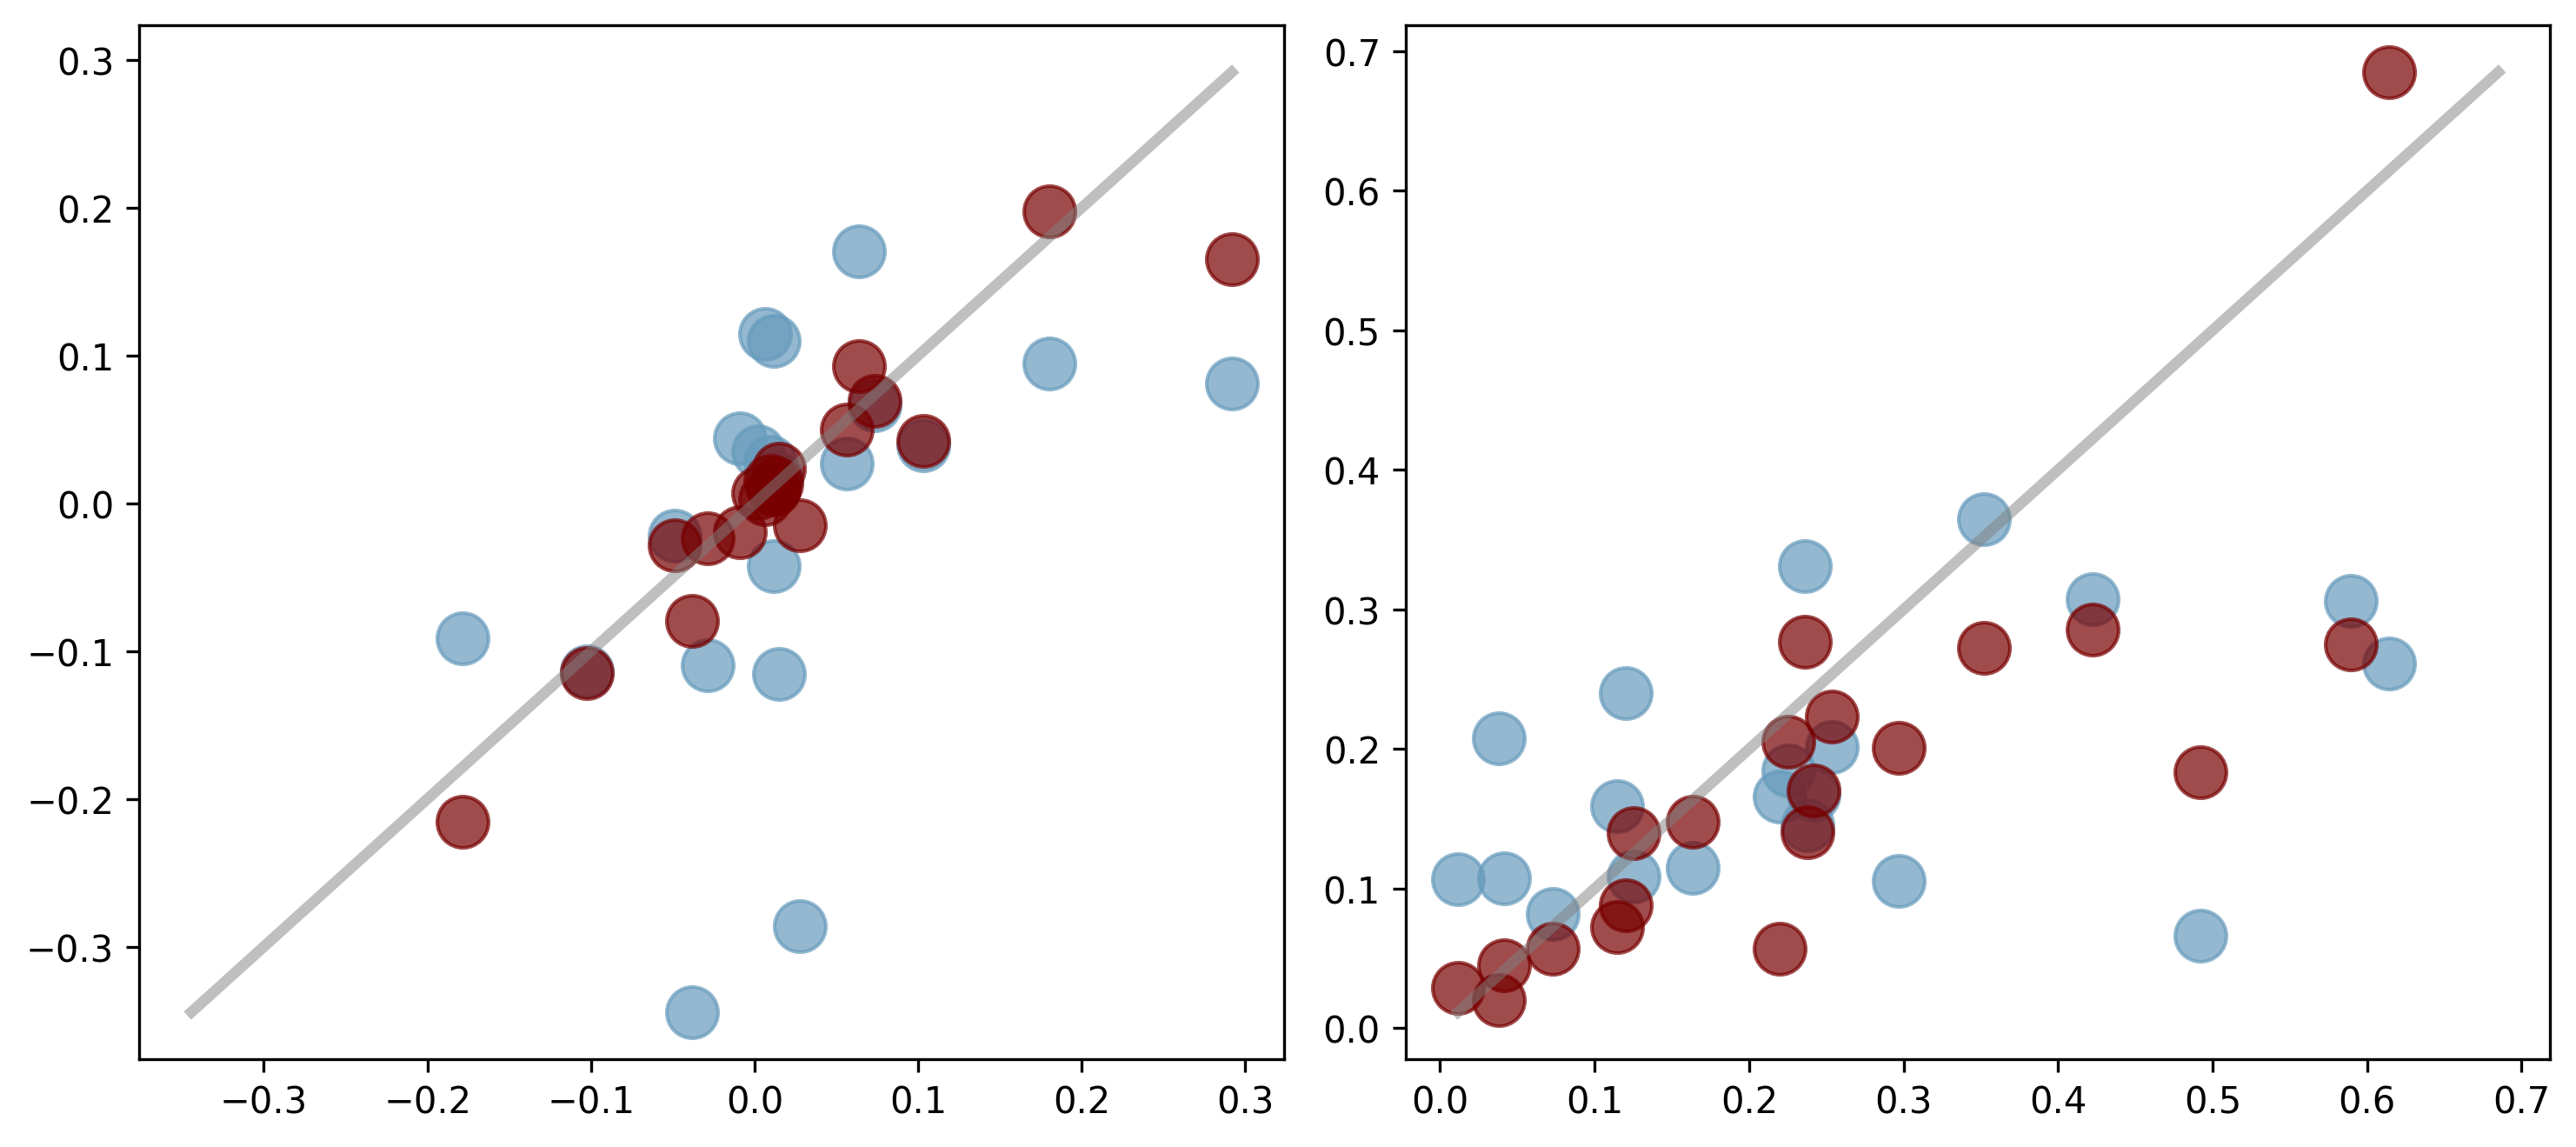

<Figure size 640x480 with 0 Axes>

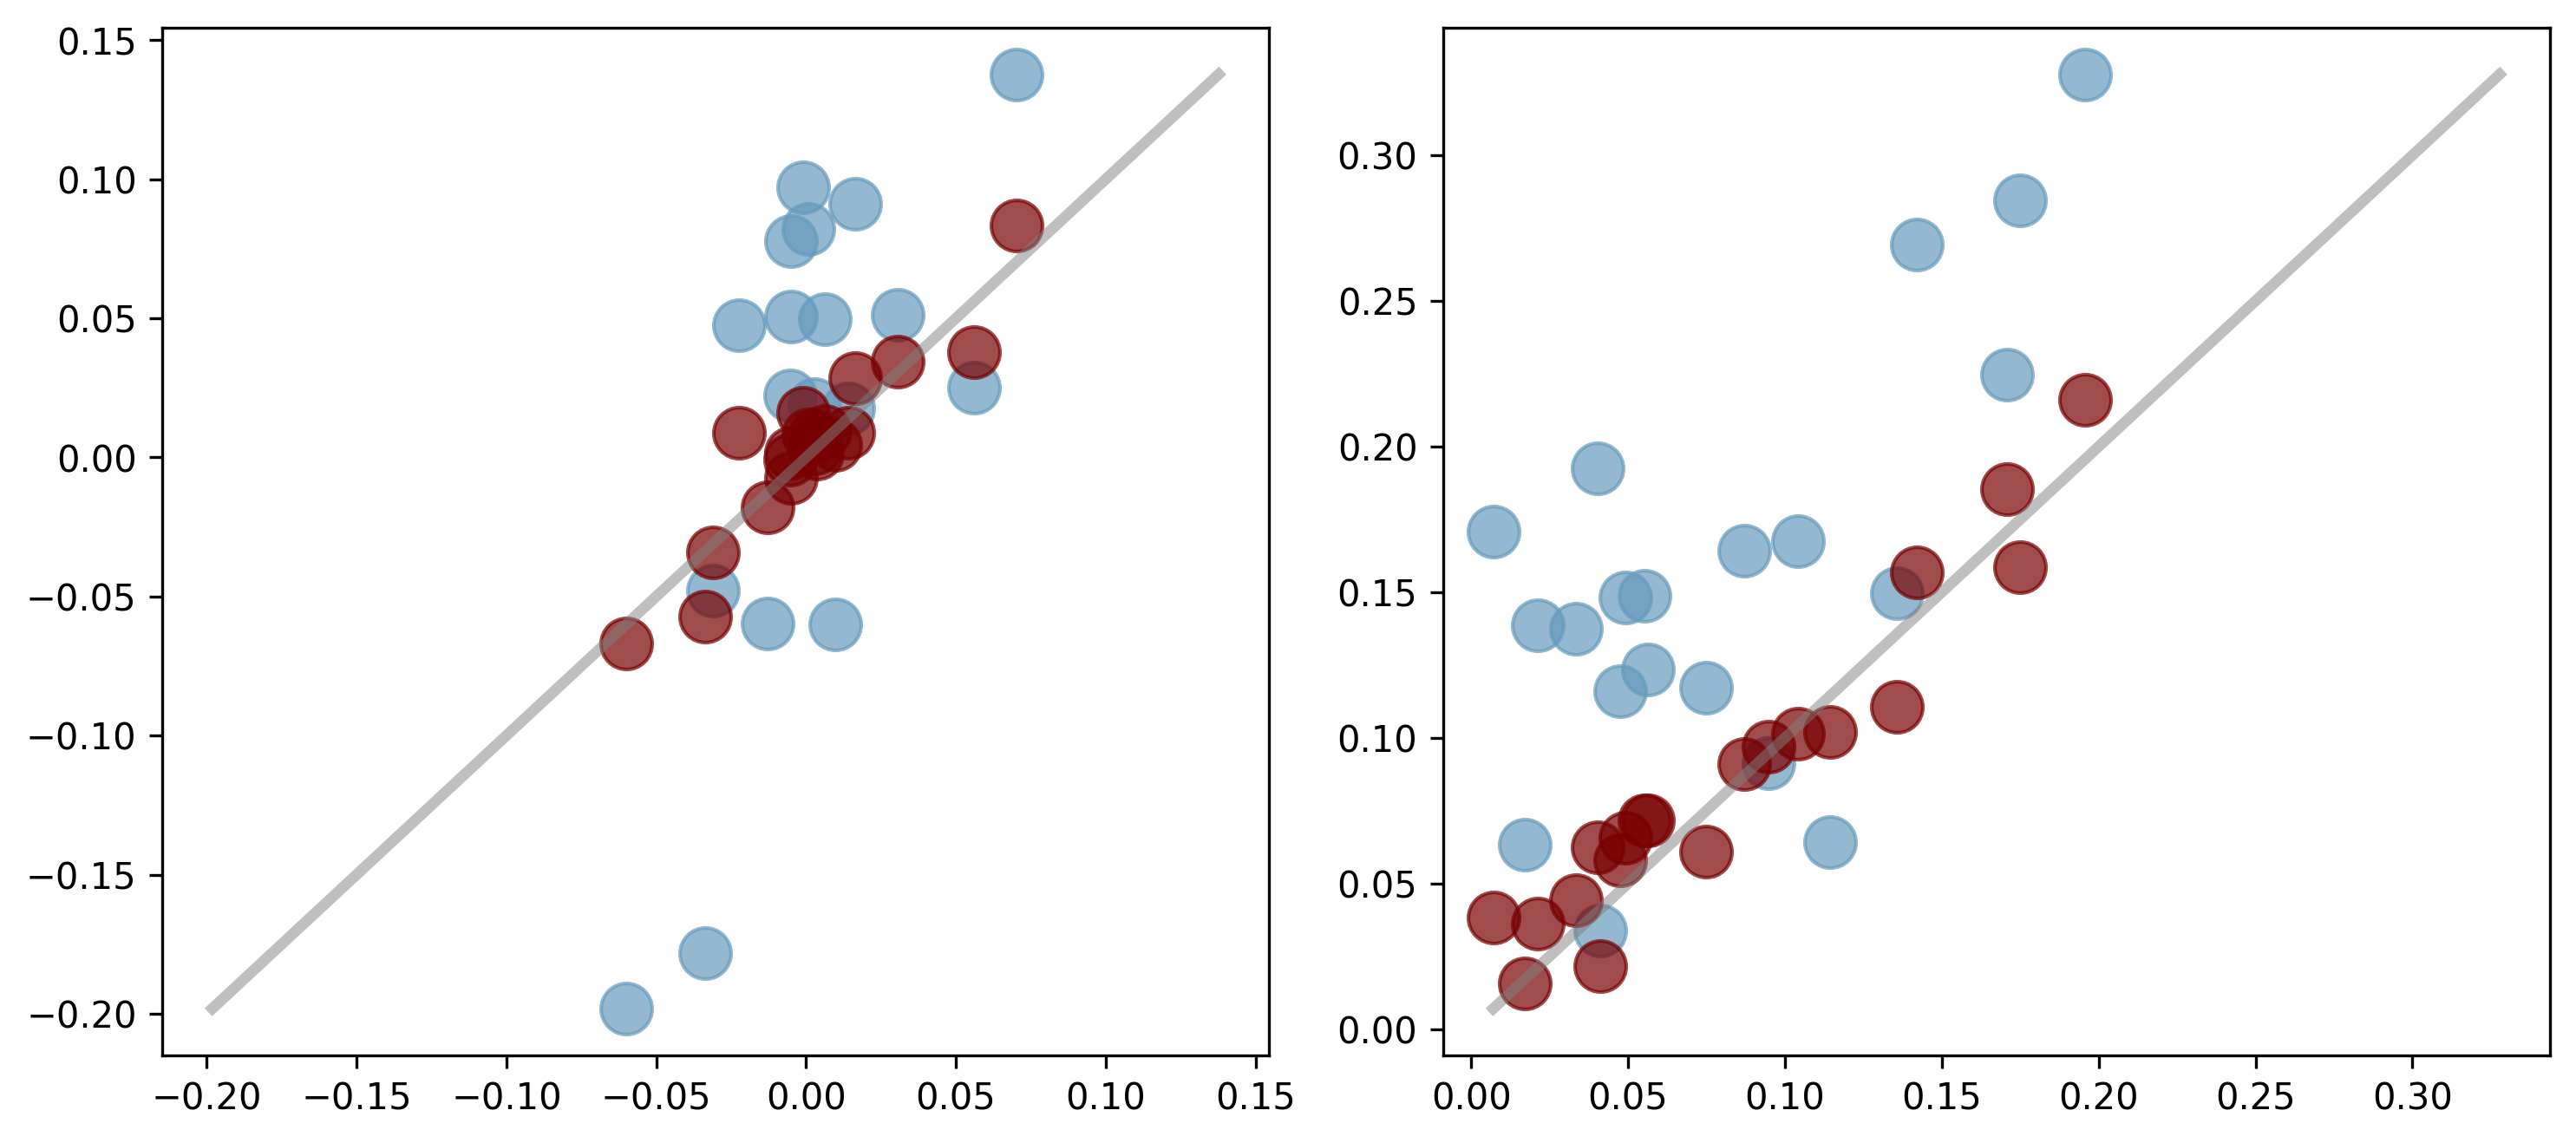

<Figure size 640x480 with 0 Axes>

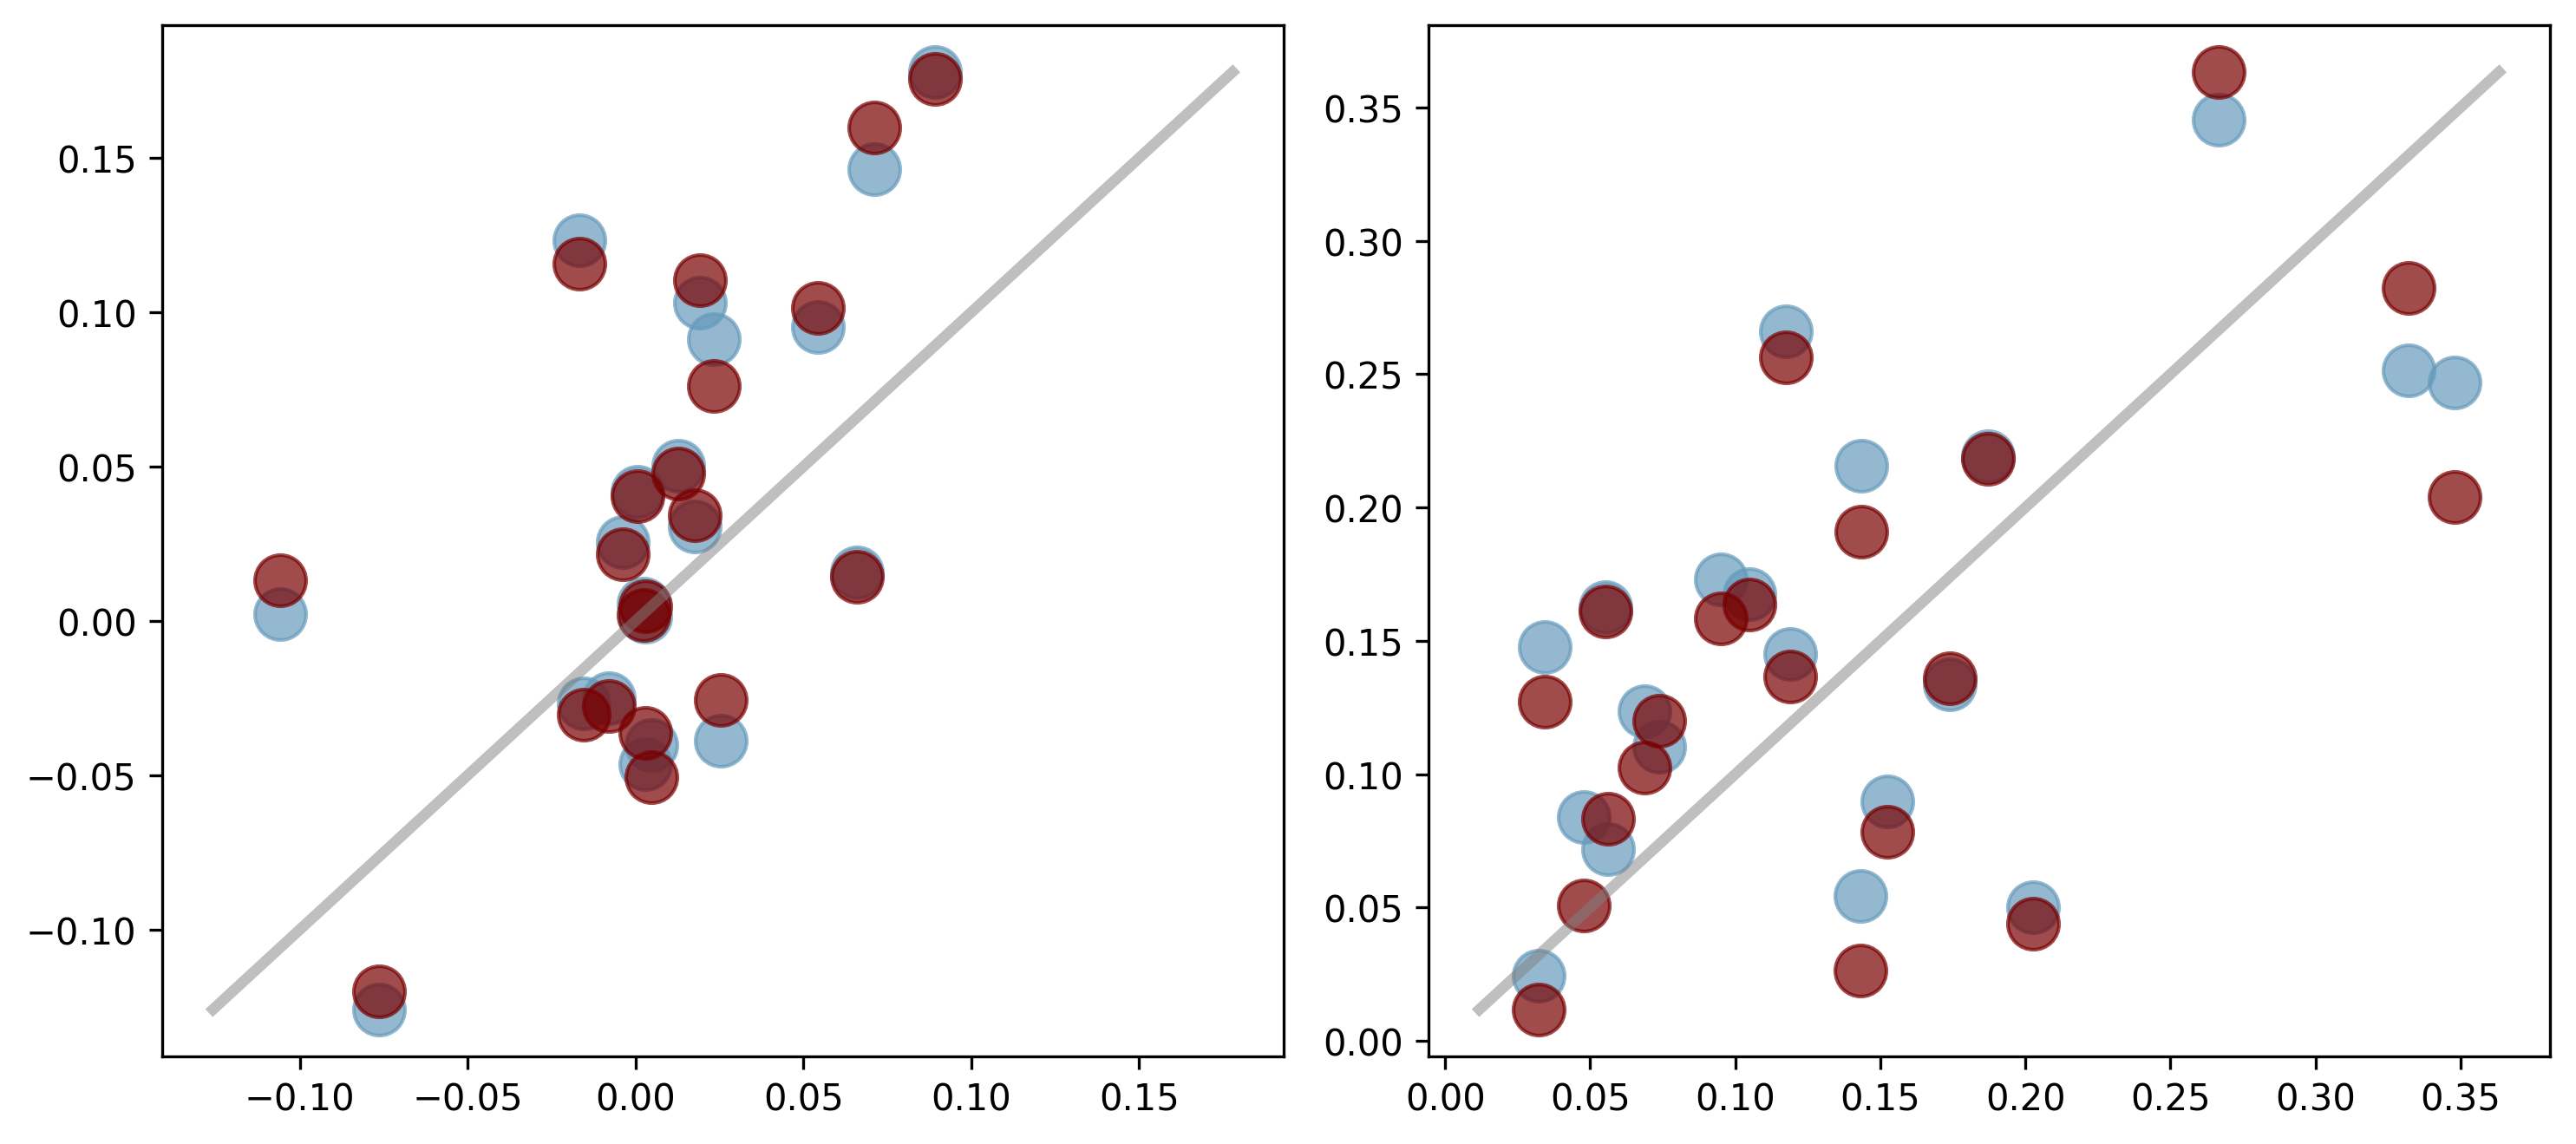

<Figure size 640x480 with 0 Axes>

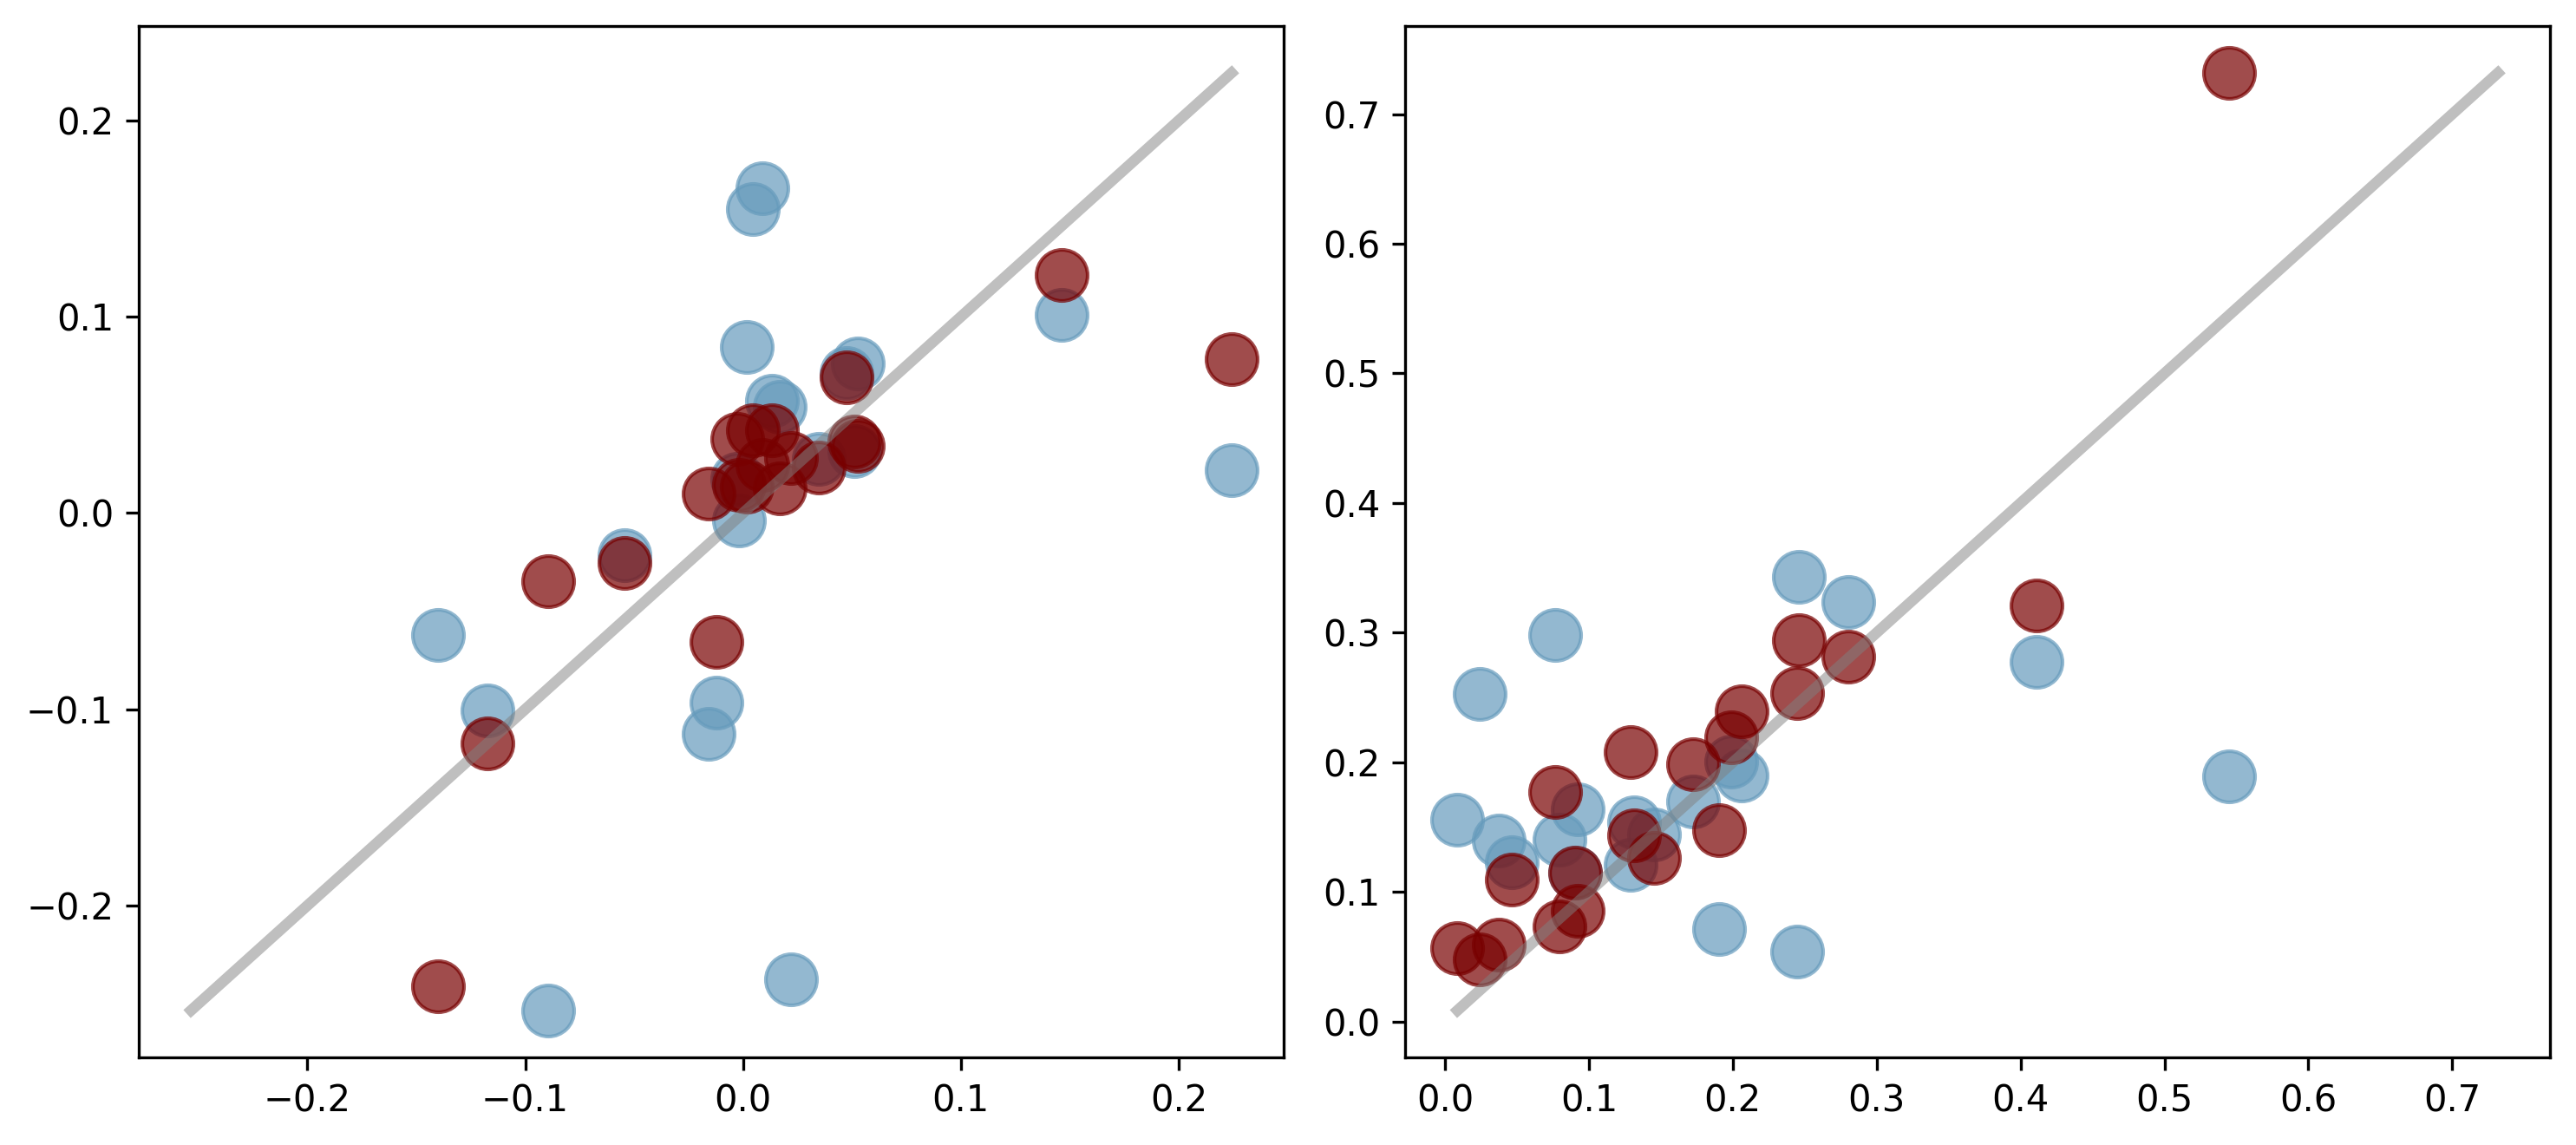

<Figure size 640x480 with 0 Axes>

In [35]:
# ---- Colors per loop ----
color_loop1 = '#669bbc'   # light blue
color_loop2 = '#780000'   # dark red

for exp_idx in range(real_marker_std.shape[0]):
    # ---- Retrieve mean value of markers -----
    x_mean = real_marker_mean[exp_idx]
    x_loop1_mean = loop1_marker_mean[exp_idx]
    x_loop2_mean = loop2_marker_mean[exp_idx]

    # ---- Retrieve std value of markers -----
    x_std = real_marker_std[exp_idx]
    x_loop1_std = loop1_marker_std[exp_idx]
    x_loop2_std = loop2_marker_std[exp_idx]

    # ---- Figure ----
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=300)
    ax_mean, ax_std = ax

    # Scatter plots (no legend entries)
    ax_mean.scatter(x_mean, x_loop1_mean, color=color_loop1, alpha=0.7, s=200)
    ax_mean.scatter(x_mean, x_loop2_mean, color=color_loop2, alpha=0.7, s=200)
    ax_std.scatter(x_std, x_loop1_std, color=color_loop1, alpha=0.7, s=200)
    ax_std.scatter(x_std, x_loop2_std, color=color_loop2, alpha=0.7, s=200)

    # ---- Diagonal reference line for mean ----
    all_vals = np.concatenate([x_mean, x_loop1_mean, x_loop2_mean])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax_mean.plot([min_val, max_val], [min_val, max_val],
                 linewidth=3, alpha=0.5, color="gray")

    # ---- Diagonal reference line for std ----
    all_vals = np.concatenate([x_std, x_loop1_std, x_loop2_std])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax_std.plot([min_val, max_val], [min_val, max_val],
                linewidth=3, alpha=0.5, color="gray")

    # ---- Save without legend ----
    fig.tight_layout()
    exp_num = exp_idx_to_num[exp_idx]
    plt.show()
    plt.savefig(f'output/comparison_exp_{exp_num:03d}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)


### Compute metrics for Reconstruction of Mean and Standard Deviation.

In [60]:
from sklearn.metrics import mean_squared_error, r2_score

metrics_dict = {}

for exp_idx in range(real_marker_std.shape[0]):
    # ---- Retrieve mean value of markers -----
    x_mean = real_marker_mean[exp_idx]
    x_loop1_mean = loop1_marker_mean[exp_idx]
    x_loop2_mean = loop2_marker_mean[exp_idx]

    # ---- Retrieve std value of markers -----
    x_std = real_marker_std[exp_idx]
    x_loop1_std = loop1_marker_std[exp_idx]
    x_loop2_std = loop2_marker_std[exp_idx]

    # ----- Compute metrics for mean ----
    mse_mean_loop1 = mean_squared_error(x_mean, x_loop1_mean)
    r2_mean_loop1 = r2_score(x_mean, x_loop1_mean)
    mse_mean_loop2 = mean_squared_error(x_mean, x_loop2_mean)
    r2_mean_loop2 = r2_score(x_mean, x_loop2_mean)
    pearson_rho_mean_loop1, pearson_rho_mean_loop1_pval  = stats.pearsonr(x_mean, x_loop1_mean)
    pearson_rho_mean_loop2, pearson_rho_mean_loop2_pval  = stats.pearsonr(x_mean, x_loop2_mean)

    # ----- Compute metrics for std ----
    mse_std_loop1 = mean_squared_error(x_std, x_loop1_std)
    r2_std_loop1 = r2_score(x_std, x_loop1_std)
    mse_std_loop2 = mean_squared_error(x_std, x_loop2_std)
    r2_std_loop2 = r2_score(x_std, x_loop2_std)
    pearson_rho_std_loop1, pearson_rho_std_loop1_pval  = stats.pearsonr(x_std, x_loop1_std)
    pearson_rho_std_loop2, pearson_rho_std_loop2_pval  = stats.pearsonr(x_std, x_loop2_std)

    # ---- Store metrics in dictionary ----
    metrics_dict[exp_idx] = {
        "MSE Mean Loop1": mse_mean_loop1,
        "MSE Mean Loop2": mse_mean_loop2,
        "Pearson Rho Mean Loop 1": pearson_rho_mean_loop1,
        "Pval Pearson Rho Mean Loop 1": pearson_rho_mean_loop1_pval,
        "Pearson Rho Mean Loop 2": pearson_rho_mean_loop2,
        "Pval Pearson Rho Mean Loop 2": pearson_rho_mean_loop2_pval,
        "R2 Mean Loop1": r2_mean_loop1,
        "R2 Mean Loop2": r2_mean_loop2,
        "MSE Std Loop1": mse_std_loop1,
        "MSE Std Loop2": mse_std_loop2,
        "Pearson Rho Std Loop 1": pearson_rho_std_loop1,
        "Pval Pearson Rho Std Loop 1": pearson_rho_std_loop1_pval,
        "Pearson Rho Std Loop 2": pearson_rho_std_loop2,
        "Pval Pearson Rho Std Loop 2": pearson_rho_std_loop2_pval,
        "R2 Std Loop1": r2_std_loop1,
        "R2 Std Loop2": r2_std_loop2,
        "Experiment Number": int(exp_idx_to_num[exp_idx])
    }

metrics_df = pd.DataFrame(metrics_dict).T
metrics_df.index = metrics_df["Experiment Number"].astype(int)
metrics_df = metrics_df.drop(columns=["Experiment Number"])
metrics_df = metrics_df.sort_index()
metrics_df.to_csv("output/metrics_comparison_loop1_loop2.csv", index=True)
metrics_df

,MSE Mean Loop1,MSE Mean Loop2,Pearson Rho Mean Loop 1,Pval Pearson Rho Mean Loop 1,Pearson Rho Mean Loop 2,Pval Pearson Rho Mean Loop 2,R2 Mean Loop1,R2 Mean Loop2,MSE Std Loop1,MSE Std Loop2,Pearson Rho Std Loop 1,Pval Pearson Rho Std Loop 1,Pearson Rho Std Loop 2,Pval Pearson Rho Std Loop 2,R2 Std Loop1,R2 Std Loop2
Experiment Number,,,,,,,,,,,,,,,,
248,0.016024,0.001330,0.440090,0.052157,0.932860,2.060223e-09,-0.790456,0.851432,0.026403,0.014093,0.458287,0.042136,0.813822,1.270454e-05,0.097020,0.518011
249,0.011026,0.002264,0.434392,0.055640,0.812228,1.363251e-05,-0.769445,0.636645,0.017806,0.003715,0.264421,0.259919,0.929985,2.972829e-09,-0.052952,0.780315
250,0.004648,0.000140,0.679335,0.000987,0.930130,2.919271e-09,-4.815762,0.825019,0.008378,0.000260,0.669730,0.001237,0.960704,1.839516e-11,-1.764320,0.914268
251,0.003811,0.003822,0.613096,0.004047,0.610820,4.225379e-03,-0.972694,-0.978575,0.006447,0.006638,0.584479,0.006802,0.583155,6.959087e-03,0.207019,0.183451


## Inspect Reduction in Uncertainty After Loop 2.

### Prepare Mapping from Experiment Number to Enrichment Type.

In [36]:
exp_num_to_enrichment_type = {
    248:"late_MgkPro",
    249: "EryPro",
    250: "preProB:0",
    251: "preProB:1",
}


### Visualize Predicted Cell Type Proportions.

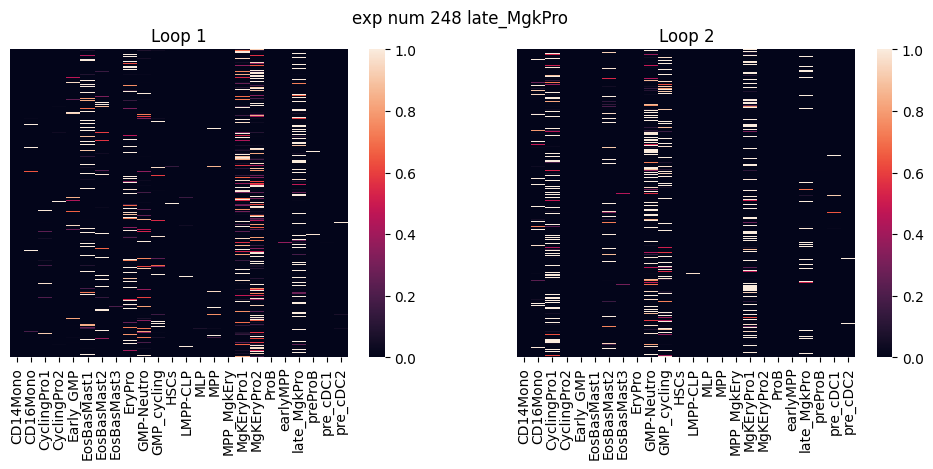

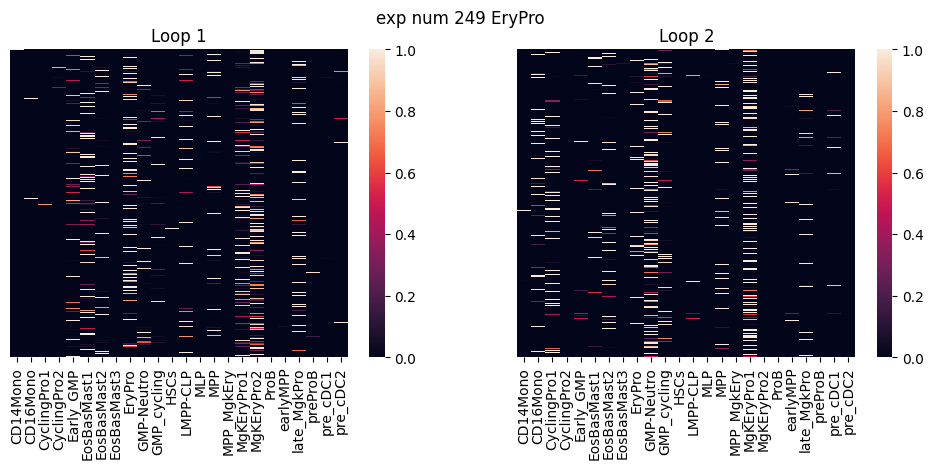

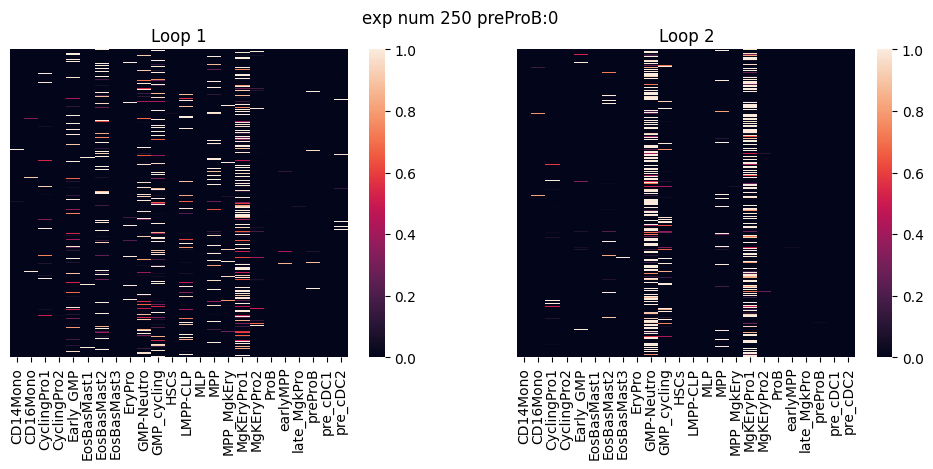

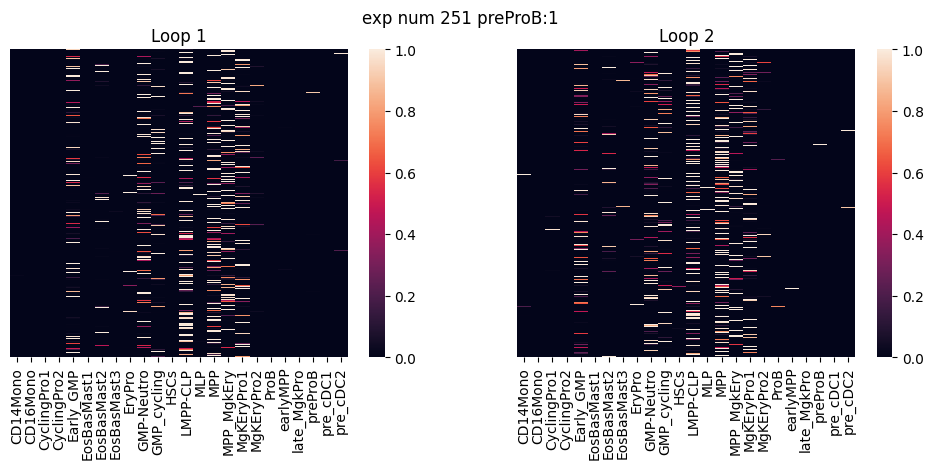

In [37]:
for exp_num, enrichment_type in exp_num_to_enrichment_type.items():
    exp_idx = exp_num_to_cond_idx[exp_num]
    fig, (ax_loop1, ax_loop2 ) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"exp num {exp_num} {enrichment_type}")

    ax_loop1.set_title("Loop 1")
    sns.heatmap(ct_probs_gen_loop1[:, exp_idx], xticklabels=classes, yticklabels=[], ax=ax_loop1)

    ax_loop2.set_title("Loop 2")
    sns.heatmap(ct_probs_gen_loop2[:, exp_idx], xticklabels=classes, yticklabels=[], ax=ax_loop2)

### Retrive Cell Type Predictions for Enrichment Type.

In [38]:
# ---- Settings for bootstrap ----
n_pops = 100
n_iters = 10

# ---- Prepare populations
enrichment_type_to_ct_preds = {}
for exp_num, enrichment_type in exp_num_to_enrichment_type.items():
    exp_idx = exp_num_to_cond_idx[exp_num]
    
    loop1_shuffled_pops = get_shuffled_populations(ct_probs_gen_loop1[:, exp_idx], n_pops=n_pops, n_iters=n_iters)
    loop2_shuffled_pops = get_shuffled_populations(ct_probs_gen_loop2[:, exp_idx], n_pops=n_pops, n_iters=n_iters)

    loop1_mean_ct_preds = loop1_shuffled_pops.mean(-2).mean(0)
    loop2_mean_ct_preds = loop2_shuffled_pops.mean(-2).mean(0)
    enrichment_type_to_ct_preds[enrichment_type] = {
        "Loop 1": loop1_mean_ct_preds,
        "Loop 2": loop2_mean_ct_preds,
    }


### Compute Variance per Cell Type.

In [39]:
enrichment_type_to_uncertainty = {}
enrichment_type_to_mean_prob = {}
for enrichment_type, probs_dict in enrichment_type_to_ct_preds.items():
    ct = enrichment_type.split(":")[0]
    ct_idx = classes.tolist().index(ct)
    print(ct_idx)
    
    enrichment_type_to_uncertainty[enrichment_type] = {
        k: v.var(-2)[..., ct_idx].item() for k, v in probs_dict.items()
    }
    enrichment_type_to_mean_prob[enrichment_type] = {
        k: v.mean(-2)[..., ct_idx].item() for k, v in probs_dict.items()
    }
enrichment_type_to_uncertainty, enrichment_type_to_mean_prob

20
8
21
21


({'late_MgkPro': {'Loop 1': 0.0005975134554319084,
   'Loop 2': 0.0004875861050095409},
  'EryPro': {'Loop 1': 0.0005274522118270397,
   'Loop 2': 0.00018294749315828085},
  'preProB:0': {'Loop 1': 2.3725797291263007e-05,
   'Loop 2': 1.3827359452989185e-06},
  'preProB:1': {'Loop 1': 1.7172522348118946e-05,
   'Loop 2': 2.523516923247371e-05}},
 {'late_MgkPro': {'Loop 1': 0.19156447052955627,
   'Loop 2': 0.10000263154506683},
  'EryPro': {'Loop 1': 0.17907020449638367, 'Loop 2': 0.04061482101678848},
  'preProB:0': {'Loop 1': 0.005159418564289808,
   'Loop 2': 0.00038671738002449274},
  'preProB:1': {'Loop 1': 0.004587347619235516,
   'Loop 2': 0.0052770525217056274}})

In [58]:
all_records = []
for ct, unc_dict in enrichment_type_to_uncertainty.items():
    mean_prob_dict = enrichment_type_to_mean_prob[ct]
    record = {
        "Cell Type": ct,
        "Loop 1 Mean Prob": mean_prob_dict["Loop 1"],
        "Loop 2 Mean Prob": mean_prob_dict["Loop 2"],
        "Loop 1 Uncertainty": unc_dict["Loop 1"],
        "Loop 2 Uncertainty": unc_dict["Loop 2"],
    }
    all_records.append(record)
unc_df = pd.DataFrame(all_records)
unc_df = unc_df.set_index("Cell Type")
unc_df.to_csv("output/uncertainty_comparison_loop1_loop2.csv")
unc_df

,Loop 1 Mean Prob,Loop 2 Mean Prob,Loop 1 Uncertainty,Loop 2 Uncertainty
Cell Type,,,,
late_MgkPro,0.191564,0.100003,0.000598,0.000488
EryPro,0.179070,0.040615,0.000527,0.000183
preProB:0,0.005159,0.000387,0.000024,0.000001
preProB:1,0.004587,0.005277,0.000017,0.000025


### Visualize Reduction in Target Uncertainty.

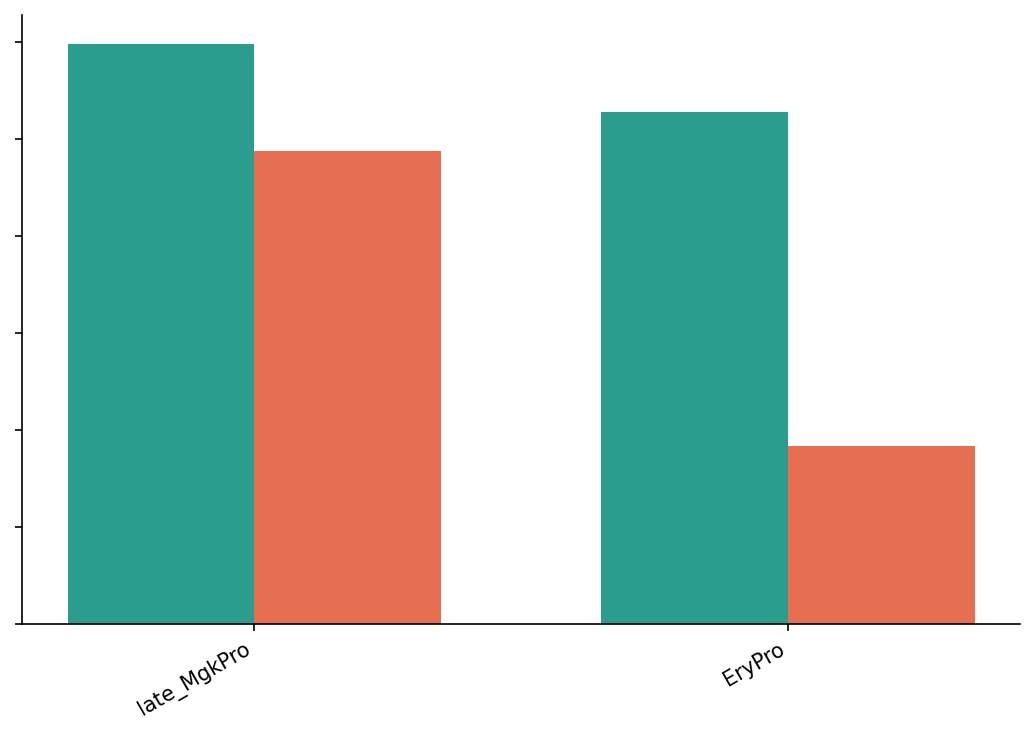

<Figure size 640x480 with 0 Axes>

In [40]:
# ---- Colors ----
color_loop1 = "#2a9d8f"
color_loop2 = "#e76f51"

# ---- Extract data from the dictionaries ----
# enrichment_types = list(enrichment_type_to_uncertainty.keys())
enrichment_types = ["late_MgkPro", "EryPro"]
unc_loop1 = [enrichment_type_to_uncertainty[et]['Loop 1'] for et in enrichment_types]
unc_loop2 = [enrichment_type_to_uncertainty[et]['Loop 2'] for et in enrichment_types]

# ---- Bar positions ----
x = np.arange(len(enrichment_types))          # the label locations
width = 0.35                                   # width of the bars

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
bars1 = ax.bar(x - width/2, unc_loop1, width, color=color_loop1, label='Loop 1')
bars2 = ax.bar(x + width/2, unc_loop2, width, color=color_loop2, label='Loop 2')

# ---- Labels and formatting ----
# ax.set_xlabel('Enrichment type')
# ax.set_ylabel('Uncertainty (variance)')
ax.set_xticks(x)
ax.set_xticklabels(enrichment_types, rotation=30, ha='right')
# ax.set_xticklabels([], rotation=30, ha='right')
ax.set_yticklabels([], rotation=30, ha='right')
ax.spines[['top', 'right']].set_visible(False)

# ---- Save the plot WITHOUT legend ----
# We explicitly remove the legend that was auto-created by the 'label' argument
# by calling legend with no handles, or by not drawing it.  The clean way:
# Do not include a legend in the saved file.
# (The labels are only used if we call ax.legend(), which we won't.)
plt.tight_layout()
plt.show()
plt.savefig('output/uncertainty_grouped_bar.png', dpi=300, bbox_inches='tight')
plt.close(fig)

## Visualize Predictions.

### Function to Construct Prediction Data.

In [41]:
# def get_adata(x_gen, x_true, x_tgt, var_names, n_scatter_feats=6):
    
#     X = np.concat((x_gen, x_true, x_tgt), axis=0)
    
#     X_channel = X[:, :-n_scatter_feats]
#     X_scatter = X[:, -n_scatter_feats:]

#     return sc.AnnData(
#         X=X_channel,
#         obsm={"X_scatter": X_scatter},
#         obs={
#             "data_type": ["gen"]*x_gen.shape[0] + \
#                 ["real"]*len(x_true) + \
#                     ["tgt"]*len(x_tgt)
#         },
#         var=pd.DataFrame(index=var_names)
#     )


### Prepare Prediction Data.

In [42]:
# # ---- Define parameters for the plots ----
# n_real_obs = 50_000 
# n_tgt_obs = 10_000 
# n_gen_obs = 10_000
# compute_neighbors_graph = False

# # ---- Retrive number of scatter features ----
# n_scatter_feats = len(scatter_cols)

# # ---- Store for the results ----
# adatas_dict = {}

# # ---- Iterate over unique conditions ----
# for idx, cond in tqdm(enumerate(X_cond)):
#     # ---- Get mask for current condition ----
#     cond_idxs = np.all(cond_data == cond, axis=1)

#     # ---- Loop 1----
#     x_true1 = X_real_trasnf1[~cond_idxs][:n_real_obs]
#     x_tgt1 = X_real_trasnf1[cond_idxs][:n_tgt_obs]

#     x1 = X_gen_loop1[:n_gen_obs, idx]

#     ct_adata_gen1 = get_adata(x1, x_true1, x_tgt1, adata_g_loop1.var_names)
#     sc.pp.neighbors(ct_adata_gen1)
#     sc.tl.umap(ct_adata_gen1)

#     # ---- Loop 2 ----
#     x_true2 = X_real_trasnf2[~cond_idxs][:n_real_obs]
#     x_tgt2 = X_real_trasnf2[cond_idxs][:n_tgt_obs]

#     # ---- Get adata ----
#     ct_adata_gen2 = get_adata(x2, x_true2, x_tgt2, adata_g_loop1.var_names)

#     # ---- Compute neighbor graph ----
#     if compute_neighbors_graph:
#         sc.pp.neighbors(ct_adata_gen2)
#         sc.tl.umap(ct_adata_gen2)

#     # ---- Update store for the results ----
#     adatas_dict[idx] = {
#         "Loop 1": ct_adata_gen1,
#         "Loop 2": ct_adata_gen2,
#     }

### Visualize Generated Cellular States.

In [43]:
# for ct_adata_gen in adatas_dict.values():
#     print("Loop 1")
#     sc.pl.embedding(ct_adata_gen["Loop 1"], "umap", color=["data_type"], s=20, frameon=False, legend_loc="on data")

#     print("Loop 2")
#     sc.pl.embedding(ct_adata_gen["Loop 2"], "umap", color=["data_type"], s=20, frameon=False, legend_loc="on data")